In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
# Paso 0: Se filtro con Excel las columnas que no se necesitan y se conjuntaron los archivos en uno solo llamado IPL_ICUMO_FILTERED.xlsx
# Se cargaron los datos en un DataFrame
df = pd.read_excel('IPL_ICUMO_FILTERED.xlsx', sheet_name='Sheet1')
df.head()

,Variable,Sector SCIAN,2005T1,2005T2,2005T3,2005T4,2006T1,2006T2,2006T3,2006T4,...,2022T3,2022T4,2023T1,2023T2,2023T3,2023T4,2024T1,2024T2,2024T3,2024T4
0,Índice global de productividad laboral de la e...,G01 Economía Global,95.906056,100.314402,97.586067,99.14715,100.649473,103.302043,101.37266,102.009656,...,92.906060,94.536923,91.196684,94.150050,93.396188,95.092117,91.559117,94.954965,94.392870,95.353683
1,Índice global de productividad laboral de la e...,G11 Actividades primarias,79.31662,81.144303,97.586067,87.62475,83.790462,88.737198,74.875528,97.638246,...,87.036412,123.589065,99.237681,111.331865,91.533703,124.111671,97.162975,113.536647,93.582796,122.722265
2,Índice global de productividad laboral de la e...,G21 Actividades secundarias,108.048997,112.547152,97.586067,112.53762,114.848149,116.068276,115.753548,113.629037,...,96.087819,94.986611,92.951631,96.495221,97.223494,95.745194,93.550633,95.781901,97.953507,95.220293
3,Índice global de productividad laboral de la e...,G31 Actividades terciarias,92.466666,97.288812,97.586067,95.087579,95.901305,99.565988,97.008408,97.933095,...,91.447313,92.206549,88.530598,90.935603,90.468518,91.679135,88.564217,91.572880,91.796205,92.292350
4,Índice global de productividad laboral de la e...,G01 Economía Global,96.474681,99.57324,97.586067,97.760037,99.81232,104.083967,100.307101,102.293809,...,93.124694,94.880172,91.175508,96.293419,94.454870,96.513654,93.006105,97.063128,96.237274,97.168154


In [ ]:
# Paso 1: Transformar el DataFrame de formato ancho a largo
df_melted = pd.melt(
    frame=df,
    id_vars=['Variable', 'Sector SCIAN'],  # Columnas que se mantienen fijas
    var_name='FECHA_STR',  # Nombre de la nueva columna con los trimestres
    value_name='VALOR'  # Nombre de la nueva columna con los valores
)
df_melted['VALOR'] = pd.to_numeric(df_melted['VALOR'], errors='coerce')
df_melted.head()

,Variable,Sector SCIAN,FECHA_STR,VALOR
0,Índice global de productividad laboral de la e...,G01 Economía Global,2005T1,95.906056
1,Índice global de productividad laboral de la e...,G11 Actividades primarias,2005T1,79.316620
2,Índice global de productividad laboral de la e...,G21 Actividades secundarias,2005T1,108.048997
3,Índice global de productividad laboral de la e...,G31 Actividades terciarias,2005T1,92.466666
4,Índice global de productividad laboral de la e...,G01 Economía Global,2005T1,96.474681


In [22]:
# Paso 2: Convertir la columna FECHA_STR a datetime
def convert_quarter_to_datetime(quarter_str):
    year = int(quarter_str[:4])
    quarter = int(quarter_str[-1])
    month = (quarter - 1) * 3 + 1
    return pd.to_datetime(f'{year}-{month:02d}')

df_melted['FECHA'] = df_melted['FECHA_STR'].apply(convert_quarter_to_datetime)

# Eliminar la columna FECHA_STR
df_melted.drop(columns=['FECHA_STR'], inplace=True)
df_melted = df_melted.sort_values(by=['Sector SCIAN', 'FECHA'])
df_melted.head()

,Variable,Sector SCIAN,VALOR,FECHA
447,Índice de productividad laboral con base en el...,Servicios privados no financieros,NaN,2005-01-01
458,Índice del costo unitario de la mano de obra c...,Servicios privados no financieros,NaN,2005-01-01
916,Índice de productividad laboral con base en el...,Servicios privados no financieros,NaN,2005-04-01
927,Índice del costo unitario de la mano de obra c...,Servicios privados no financieros,NaN,2005-04-01
1385,Índice de productividad laboral con base en el...,Servicios privados no financieros,NaN,2005-07-01


In [23]:
def quitar_digitos(sector):
    return sector.split(' ', 1)[1] if ' ' in sector else sector

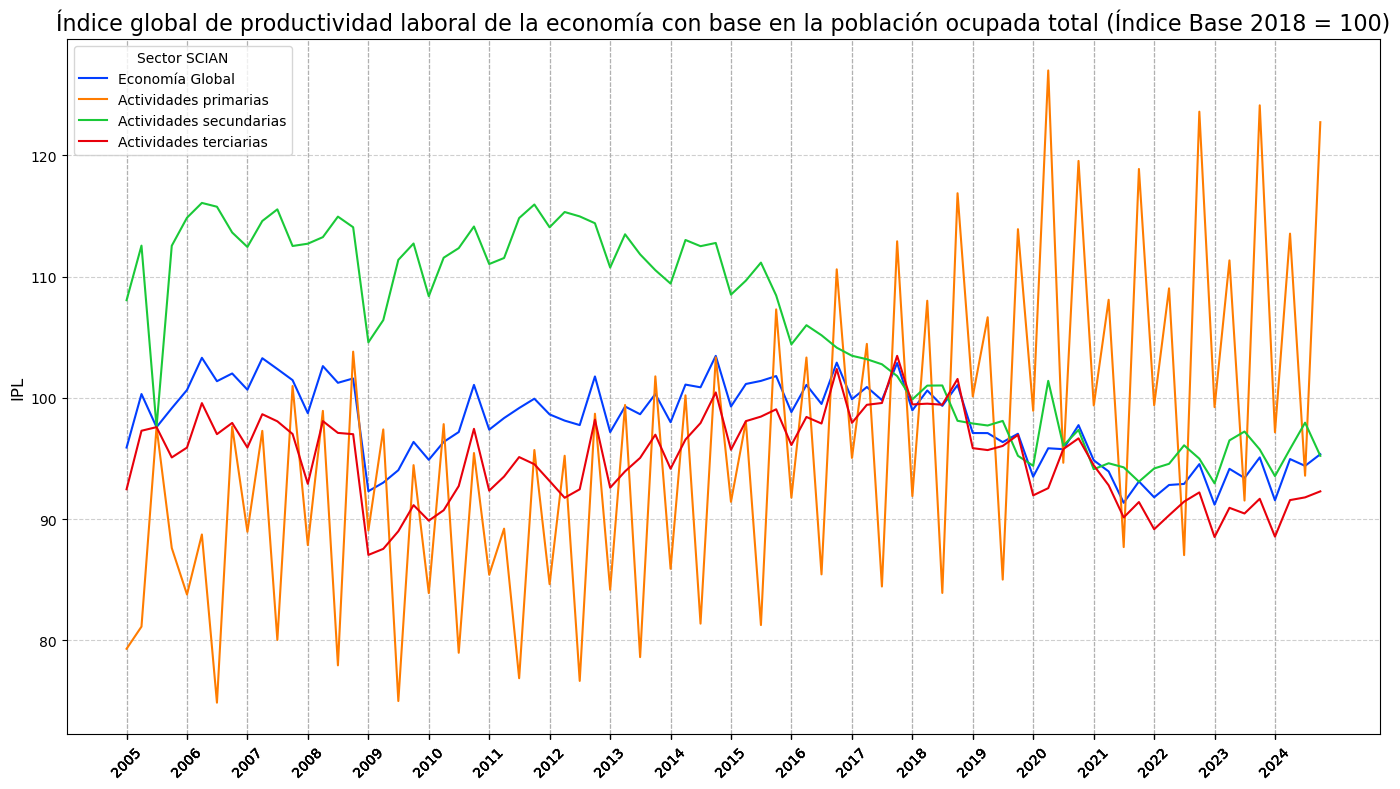

In [24]:
# Paso 3: Graficar una serie de tiempo para los indices globales
df_global = df_melted[df_melted['Sector SCIAN'].isin([
    'G01 Economía Global', 
    'G11 Actividades primarias', 
    'G21 Actividades secundarias', 
    'G31 Actividades terciarias'
])]
df_global_ocupacion = df_global[df_global['Variable'] == 'Índice global de productividad laboral de la economía con base en la población ocupada total']

# Aplicar la función para quitar los dígitos al principio de las etiquetas
df_global_ocupacion.loc[:, 'Sector SCIAN'] = df_global_ocupacion['Sector SCIAN'].apply(quitar_digitos)


plt.figure(figsize=(14, 8))
sns.lineplot(
    data=df_global_ocupacion,
    x='FECHA',
    y='VALOR',
    hue='Sector SCIAN',
    palette='bright'
)

plt.title('Índice global de productividad laboral de la economía con base en la población ocupada total (Índice Base 2018 = 100)', fontsize=16)
plt.ylabel('IPL', fontsize=12)
plt.xlabel('')

plt.xticks(
    ticks=df_global_ocupacion['FECHA'][::4],
    labels=df_global_ocupacion['FECHA'].dt.year[::4],
    rotation=45
)

plt.legend(title='Sector SCIAN', loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

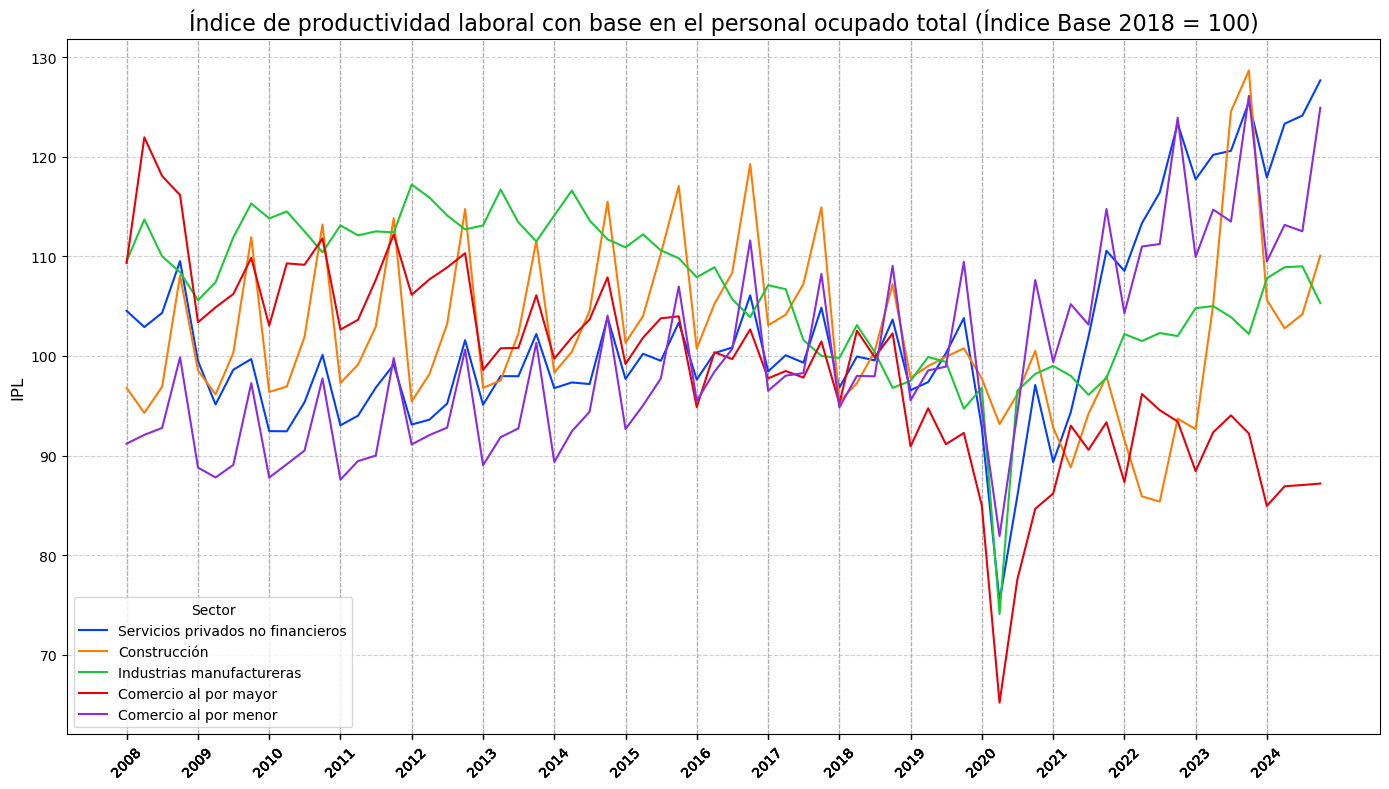

In [25]:
# Paso 4: Comparar sectores del mismo nivel (2 digitos) con IPL
df_two_digits = df_melted[df_melted['Sector SCIAN'].isin(['23 Construcción', '31-33 Industrias manufactureras', '43 Comercio al por mayor', '46 Comercio al por menor', ' Servicios privados no financieros'])]

df_two_digits_ocupacion = df_two_digits[df_two_digits['Variable'] == 'Índice de productividad laboral con base en el personal ocupado total']
df_two_digits_ocupacion = df_two_digits_ocupacion[df_two_digits_ocupacion['FECHA'].dt.year >= 2008]

# Aplicar la función para quitar los dígitos al principio de las etiquetas
df_two_digits_ocupacion.loc[:, 'Sector SCIAN'] = df_two_digits_ocupacion['Sector SCIAN'].apply(quitar_digitos)

plt.figure(figsize=(14, 8))
sns.lineplot(
    data=df_two_digits_ocupacion,
    x='FECHA',
    y='VALOR',
    hue='Sector SCIAN',
    palette='bright'
)

plt.title('Índice de productividad laboral con base en el personal ocupado total (Índice Base 2018 = 100)', fontsize=16)
plt.ylabel('IPL', fontsize=12)
plt.xlabel('')

plt.xticks(
    ticks=df_two_digits_ocupacion['FECHA'][::4],
    labels=df_two_digits_ocupacion['FECHA'].dt.year[::4],
    rotation=45
)

plt.legend(title='Sector', loc='lower left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

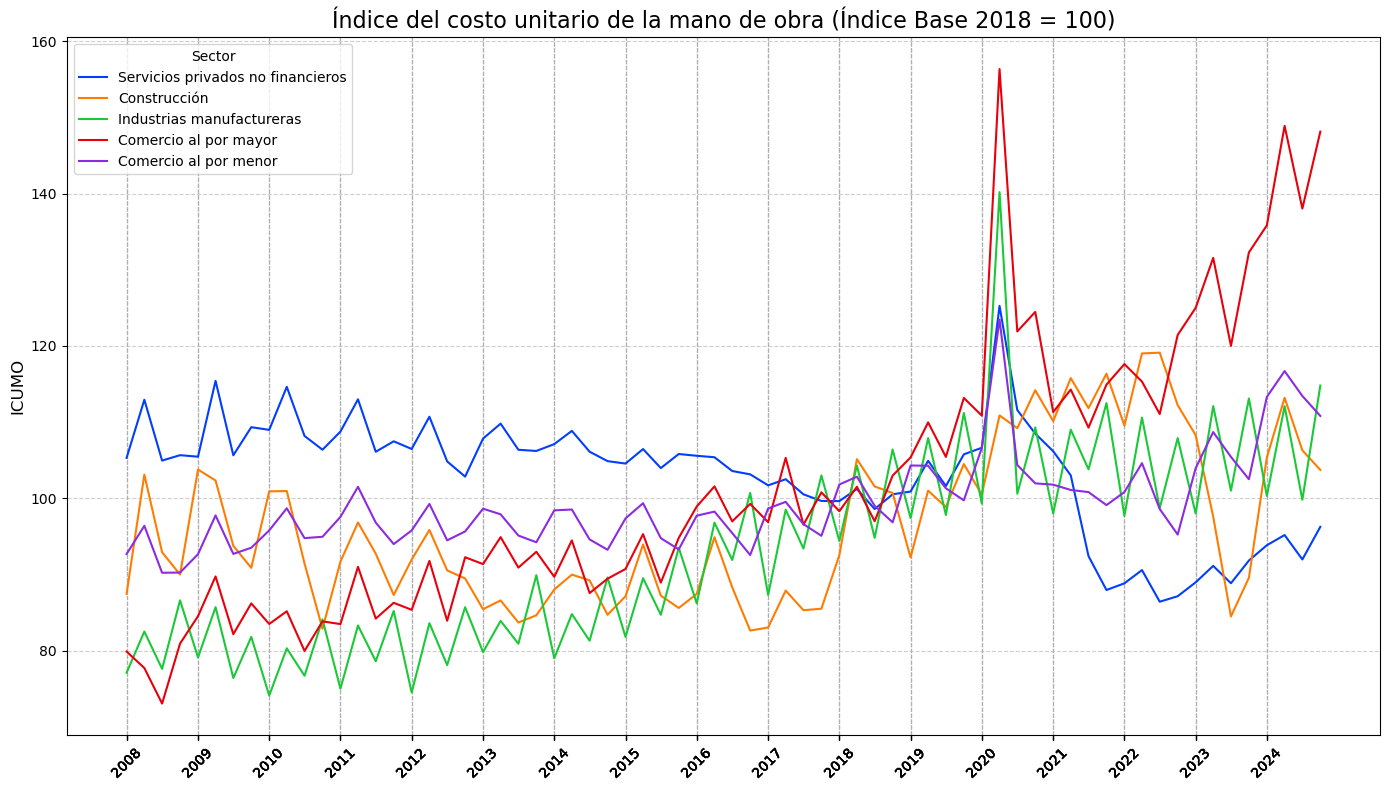

In [26]:
# Paso 4.5: Comparar sectores del mismo nivel (2 digitos) con mano de obra
df_two_digits_mano_de_obra = df_two_digits[(df_two_digits['Variable'] == 'Índice del costo unitario de la mano de obra con base en el personal ocupado total') |
                                           ((df_two_digits['Variable'] == 'Índice del costo unitario de la mano de obra con base en las horas trabajadas totales') &
                                            (df_two_digits['Sector SCIAN'].str.startswith('3')))]
df_two_digits_mano_de_obra = df_two_digits_mano_de_obra[df_two_digits_mano_de_obra['FECHA'].dt.year >= 2008]

# Aplicar la función para quitar los dígitos al principio de las etiquetas
df_two_digits_mano_de_obra.loc[:, 'Sector SCIAN'] = df_two_digits_mano_de_obra['Sector SCIAN'].apply(quitar_digitos)

plt.figure(figsize=(14, 8))
sns.lineplot(
    data=df_two_digits_mano_de_obra,
    x='FECHA',
    y='VALOR',
    hue='Sector SCIAN',
    palette='bright'
)

plt.title('Índice del costo unitario de la mano de obra (Índice Base 2018 = 100)', fontsize=16)
plt.ylabel('ICUMO', fontsize=12)
plt.xlabel('')

plt.xticks(
    ticks=df_two_digits_mano_de_obra['FECHA'][::4],
    labels=df_two_digits_mano_de_obra['FECHA'].dt.year[::4],
    rotation=45
)

plt.legend(title='Sector', loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

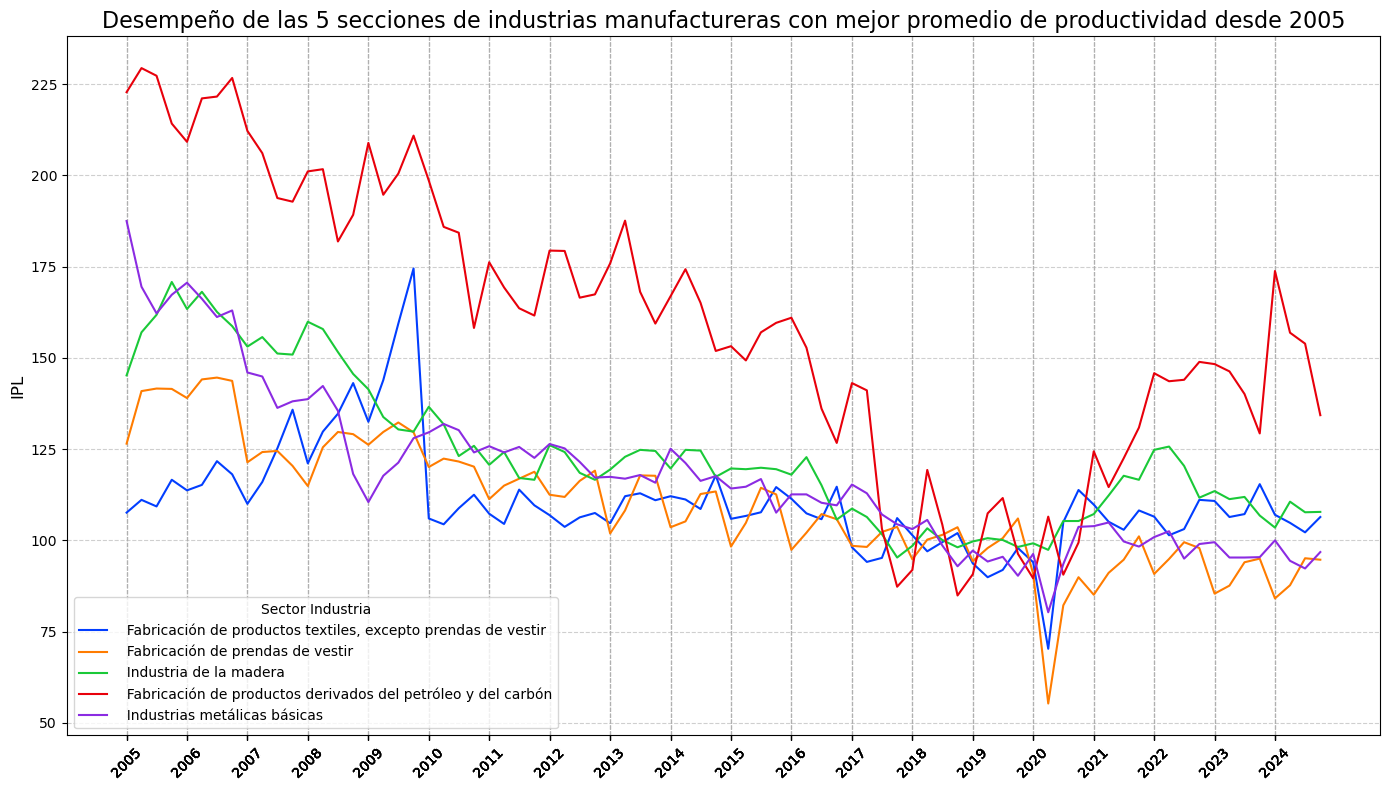

In [27]:
# Paso 5: Comparar sectores del mismo nivel (3 digitos) en manufactura con IPL
df_three_digits_man = df_melted[
    (df_melted['Sector SCIAN'].str[:3].str.isdigit()) &  # Los primeros 3 caracteres son dígitos
    (df_melted['Sector SCIAN'].str[0] == '3') &
    (df_melted['Sector SCIAN'].str[3] == ' ')  # Tiene exactamente 3 dígitos
]
df_three_digits_man_ocupacion = df_three_digits_man[df_three_digits_man['Variable'] == 'Índice de productividad laboral con base en el personal ocupado total']
desempeno_secciones_man_ocupacion = df_three_digits_man_ocupacion.groupby('Sector SCIAN')['VALOR'].mean().reset_index()
desempeno_secciones_man_ocupacion = desempeno_secciones_man_ocupacion.sort_values(by='VALOR', ascending=False)
df_three_digits_man_ocupacion = df_three_digits_man_ocupacion[df_three_digits_man_ocupacion['Sector SCIAN'].isin(desempeno_secciones_man_ocupacion.head(5)['Sector SCIAN'])]

# Aplicar la función para quitar los dígitos al principio de las etiquetas
df_three_digits_man_ocupacion.loc[:, 'Sector SCIAN'] = df_three_digits_man_ocupacion['Sector SCIAN'].apply(quitar_digitos)

plt.figure(figsize=(14, 8))
sns.lineplot(
    data=df_three_digits_man_ocupacion,
    x='FECHA',
    y='VALOR',
    hue='Sector SCIAN',
    palette='bright',
)

plt.title('Desempeño de las 5 secciones de industrias manufactureras con mejor promedio de productividad desde 2005', fontsize=16)
plt.ylabel('IPL', fontsize=12)
plt.xlabel('')

plt.xticks(
    ticks=df_three_digits_man_ocupacion['FECHA'][::4],
    labels=df_three_digits_man_ocupacion['FECHA'].dt.year[::4],
    rotation=45
)

plt.legend(title='Sector Industria', loc='lower left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

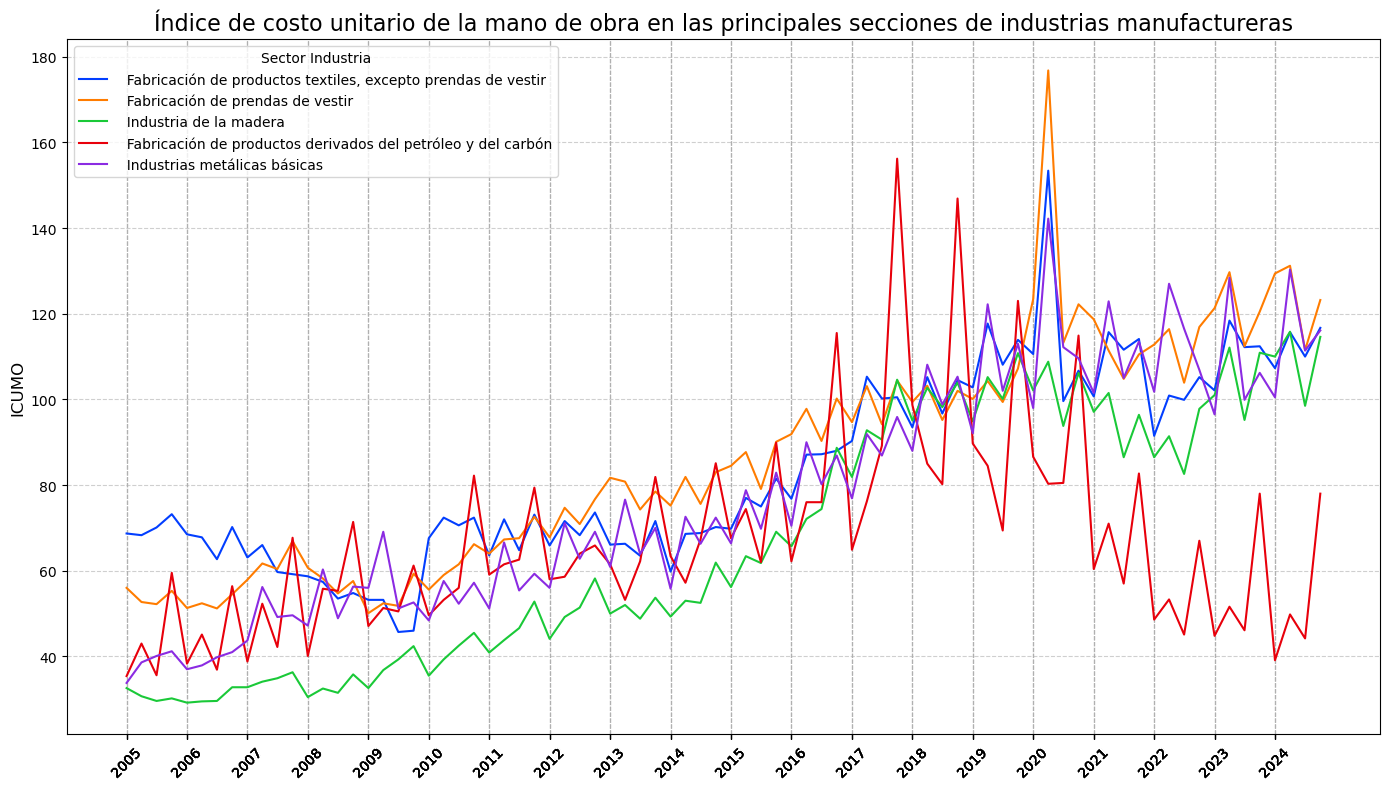

In [28]:
# Paso 5.5: Comparar sectores del mismo nivel (3 digitos) en manufactura con mano de obra
df_three_digits_man_mo = df_melted[(df_melted['Variable'] == 'Índice del costo unitario de la mano de obra con base en las horas trabajadas totales' ) & 
                                   (df_melted['Sector SCIAN'].isin(desempeno_secciones_man_ocupacion.head(5)['Sector SCIAN'].values))]

# Aplicar la función para quitar los dígitos al principio de las etiquetas
df_three_digits_man_mo.loc[:, 'Sector SCIAN'] = df_three_digits_man_mo['Sector SCIAN'].apply(quitar_digitos)

plt.figure(figsize=(14, 8))
sns.lineplot(
    data=df_three_digits_man_mo,
    x='FECHA',
    y='VALOR',
    hue='Sector SCIAN',
    palette='bright',
)

plt.title('Índice de costo unitario de la mano de obra en las principales secciones de industrias manufactureras', fontsize=16)
plt.ylabel('ICUMO', fontsize=12)
plt.xlabel('')

plt.xticks(
    ticks=df_three_digits_man_mo['FECHA'][::4],
    labels=df_three_digits_man_mo['FECHA'].dt.year[::4],
    rotation=45
)

plt.legend(title='Sector Industria', loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

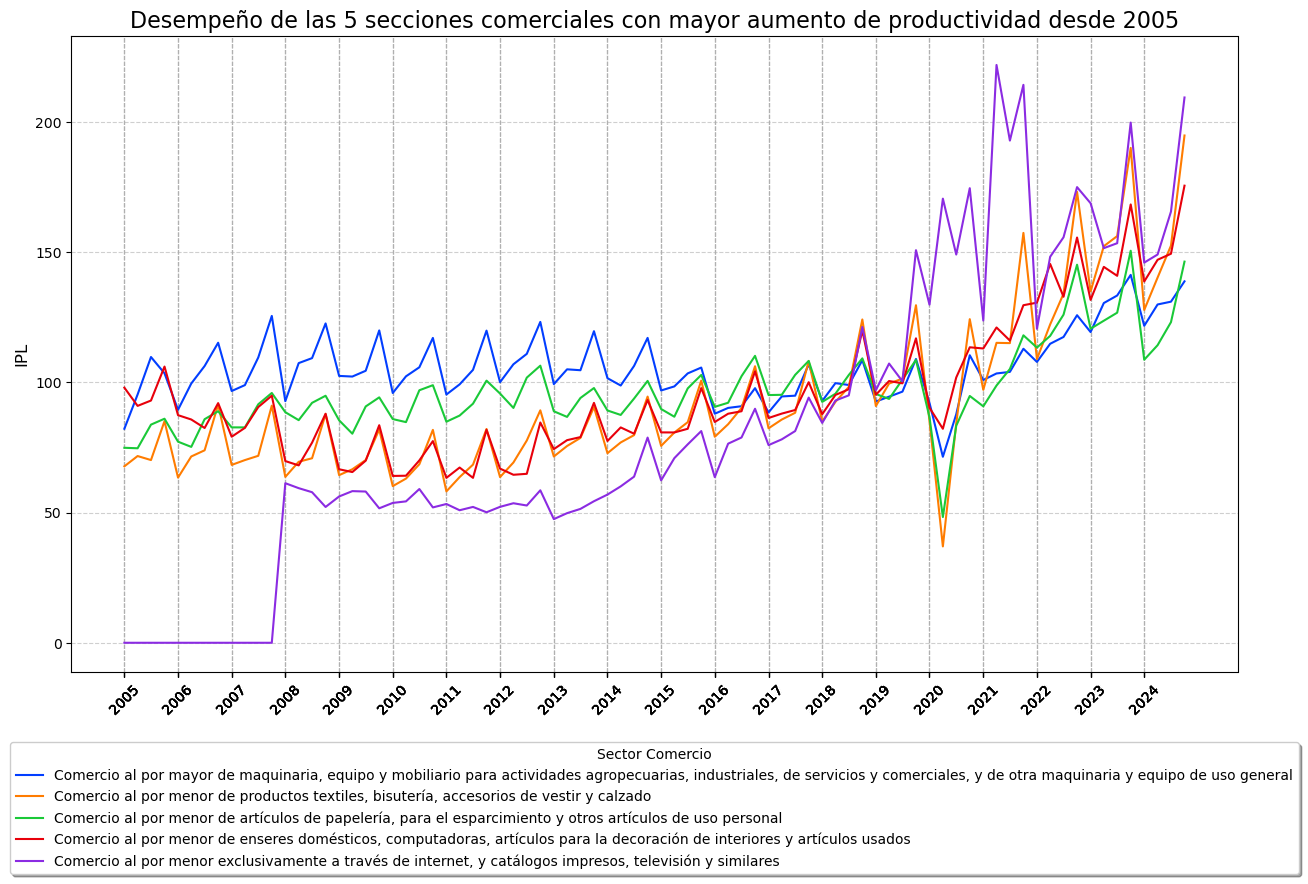

In [29]:
# Paso 6: Comparar sectores del mismo nivel (3 digitos) en comercio
df_three_digits_com = df_melted[
    (df_melted['Sector SCIAN'].str[:3].str.isdigit()) &  # Los primeros 3 caracteres son dígitos
    (df_melted['Sector SCIAN'].str[0] == '4') &
    (df_melted['Sector SCIAN'].str[3] == ' ')  # Tiene exactamente 3 dígitos
]

df_three_digits_com = df_three_digits_com[df_three_digits_com['Variable'] == 'Índice de productividad laboral con base en el personal ocupado total']
desempeno_secciones_com = df_three_digits_com.groupby('Sector SCIAN')['VALOR'].apply(lambda group: group.iloc[-1] - group.iloc[0]).reset_index()
desempeno_secciones_com = desempeno_secciones_com.sort_values(by='VALOR', ascending=False)
df_three_digits_com = df_three_digits_com[df_three_digits_com['Sector SCIAN'].isin(desempeno_secciones_com.head(5)['Sector SCIAN'])]

# Aplicar la función para quitar los dígitos al principio de las etiquetas
df_three_digits_com.loc[:, 'Sector SCIAN'] = df_three_digits_com['Sector SCIAN'].apply(quitar_digitos)

plt.figure(figsize=(14, 9))
sns.lineplot(
    data=df_three_digits_com,
    x='FECHA',
    y='VALOR',
    hue='Sector SCIAN',
    palette='bright'
)

plt.title('Desempeño de las 5 secciones comerciales con mayor aumento de productividad desde 2005', fontsize=16)
plt.ylabel('IPL', fontsize=12)
plt.xlabel('')

plt.xticks(
    ticks=df_three_digits_com['FECHA'][::4],
    labels=df_three_digits_com['FECHA'].dt.year[::4],
    rotation=45
)

plt.legend(
    title='Sector Comercio',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.1),
    ncol=1,
    fontsize='medium',
    frameon=True,
    fancybox=True,
    shadow=True
)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

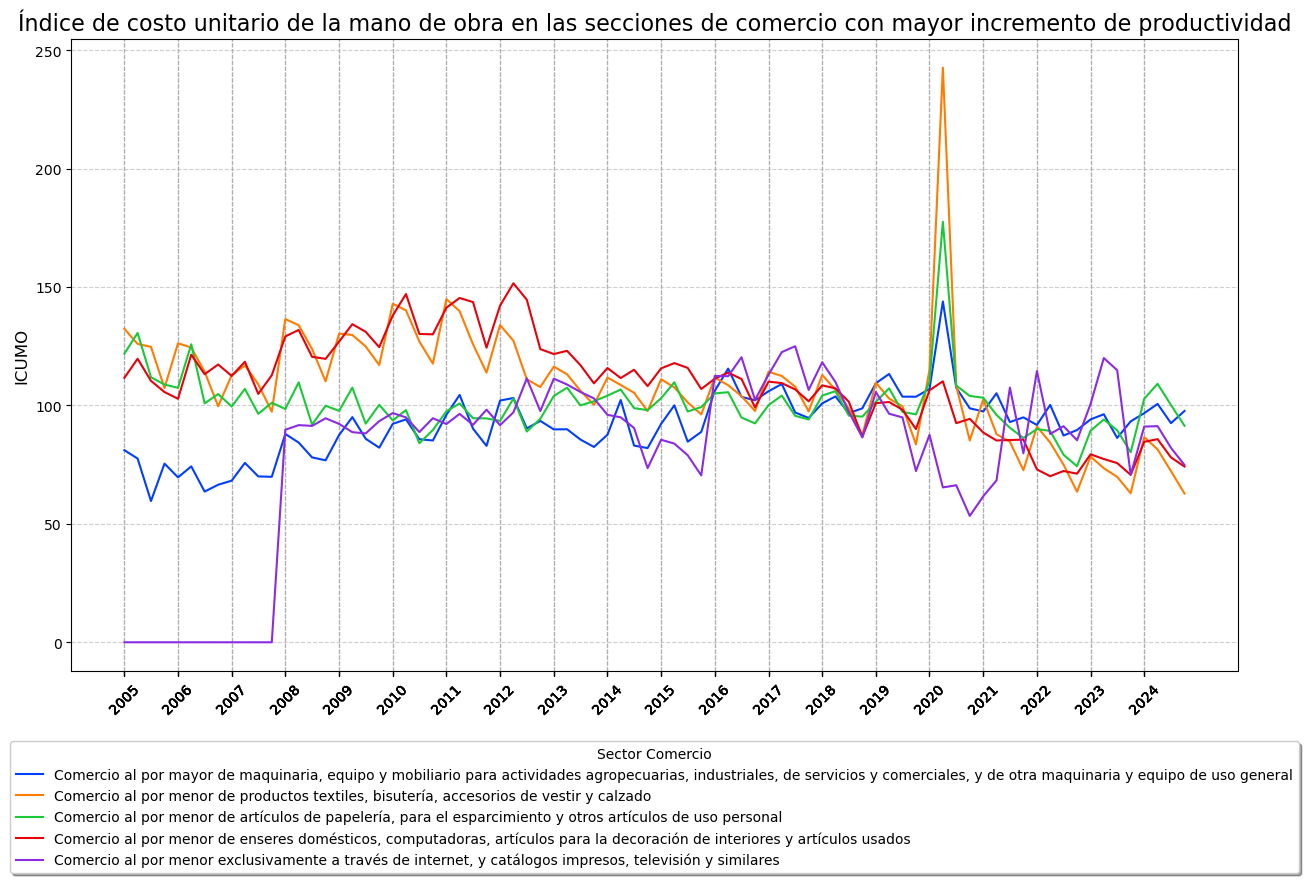

In [30]:
# Paso 6.5: Comparar sectores del mismo nivel (3 digitos) en comercio con mano de obra
df_three_digits_com_mo = df_melted[(df_melted['Variable'] == 'Índice del costo unitario de la mano de obra con base en el personal ocupado total' ) & 
                                   (df_melted['Sector SCIAN'].isin(desempeno_secciones_com.head(5)['Sector SCIAN'].values))]

# Aplicar la función para quitar los dígitos al principio de las etiquetas
df_three_digits_com_mo.loc[:, 'Sector SCIAN'] = df_three_digits_com_mo['Sector SCIAN'].apply(quitar_digitos)

plt.figure(figsize=(14, 9))
sns.lineplot(
    data=df_three_digits_com_mo,
    x='FECHA',
    y='VALOR',
    hue='Sector SCIAN',
    palette='bright',
)

plt.title('Índice de costo unitario de la mano de obra en las secciones de comercio con mayor incremento de productividad', fontsize=16)
plt.ylabel('ICUMO', fontsize=12)
plt.xlabel('')

plt.xticks(
    ticks=df_three_digits_com_mo['FECHA'][::4],
    labels=df_three_digits_com_mo['FECHA'].dt.year[::4],
    rotation=45
)

plt.legend(
    title='Sector Comercio',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.1),  # Mover la leyenda debajo de la gráfica
    ncol=1,
    fontsize='medium',
    frameon=True,
    fancybox=True,
    shadow=True
)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

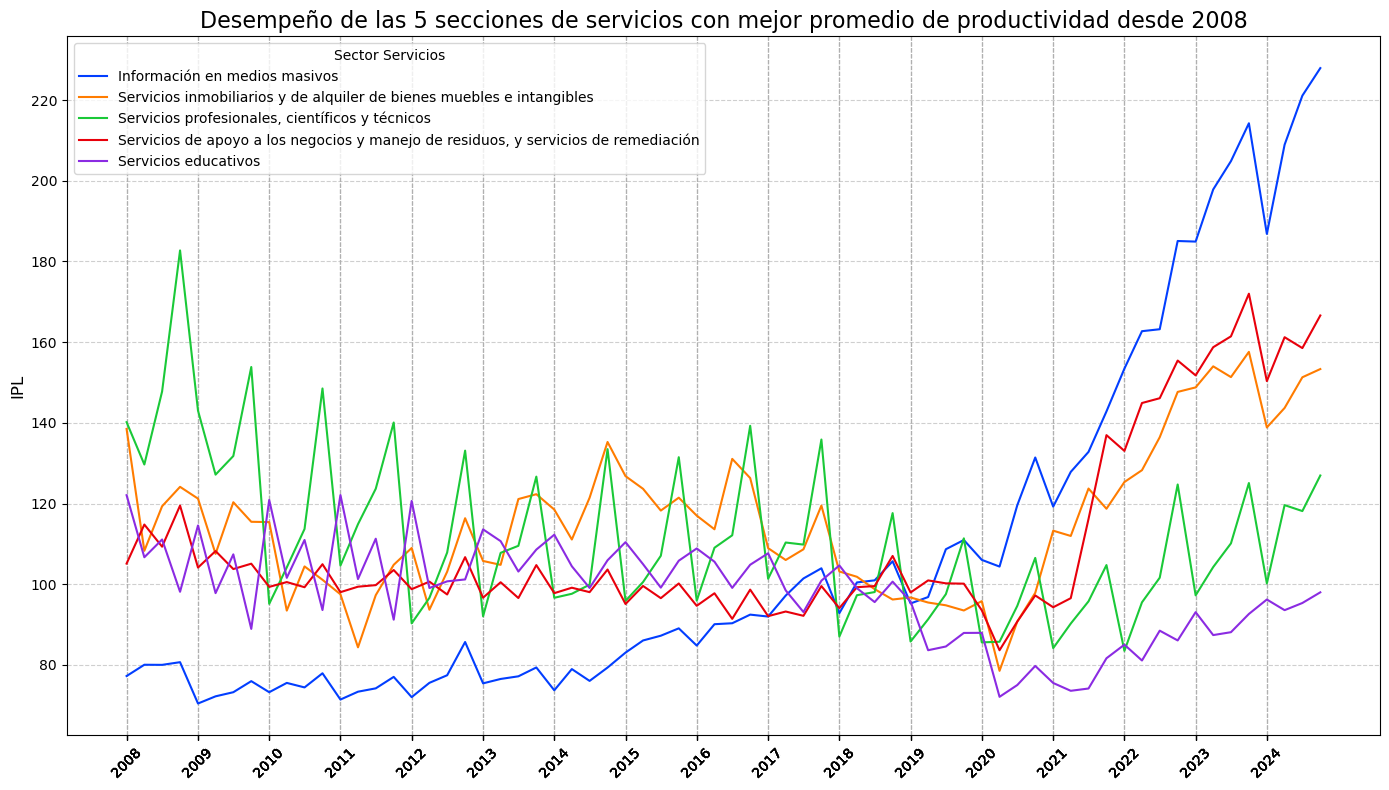

In [31]:
# Paso 7: Comparar sectores del mismo nivel (2 digitos) en servicios
df_servicios = df_melted[df_melted['Sector SCIAN'].isin(['48-49 Transportes, correos y almacenamiento',
    '51 Información en medios masivos',
    '53 Servicios inmobiliarios y de alquiler de bienes muebles e intangibles',
    '54 Servicios profesionales, científicos y técnicos',
    '56 Servicios de apoyo a los negocios y manejo de residuos, y servicios de remediación',
    '61 Servicios educativos',
    '62 Servicios de salud y de asistencia social',
    '71 Servicios de esparcimiento culturales y deportivos, y otros servicios recreativos',
    '72 Servicios de alojamiento temporal y de preparación de alimentos y bebidas'
    # '81 Otros servicios excepto actividades gubernamentales'
])]
df_servicios = df_servicios[df_servicios['Variable'] == 'Índice de productividad laboral con base en el personal ocupado total']
desempeno_servicios = df_servicios.groupby('Sector SCIAN')['VALOR'].mean().reset_index()
desempeno_servicios = desempeno_servicios.sort_values(by='VALOR', ascending=False)
df_servicios = df_servicios[df_servicios['Sector SCIAN'].isin(desempeno_servicios.head(5)['Sector SCIAN'])]
df_servicios = df_servicios[df_servicios['FECHA'].dt.year >= 2008]

# Aplicar la función para quitar los dígitos al principio de las etiquetas
df_servicios.loc[:, 'Sector SCIAN'] = df_servicios['Sector SCIAN'].apply(quitar_digitos)

plt.figure(figsize=(14, 8))
sns.lineplot(
    data=df_servicios,
    x='FECHA',
    y='VALOR',
    hue='Sector SCIAN',
    palette='bright'
)

plt.title('Desempeño de las 5 secciones de servicios con mejor promedio de productividad desde 2008', fontsize=16)
plt.ylabel('IPL', fontsize=12)
plt.xlabel('')

plt.xticks(
    ticks=df_servicios['FECHA'][::4],
    labels=df_servicios['FECHA'].dt.year[::4],
    rotation=45
)

plt.legend(title='Sector Servicios', loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

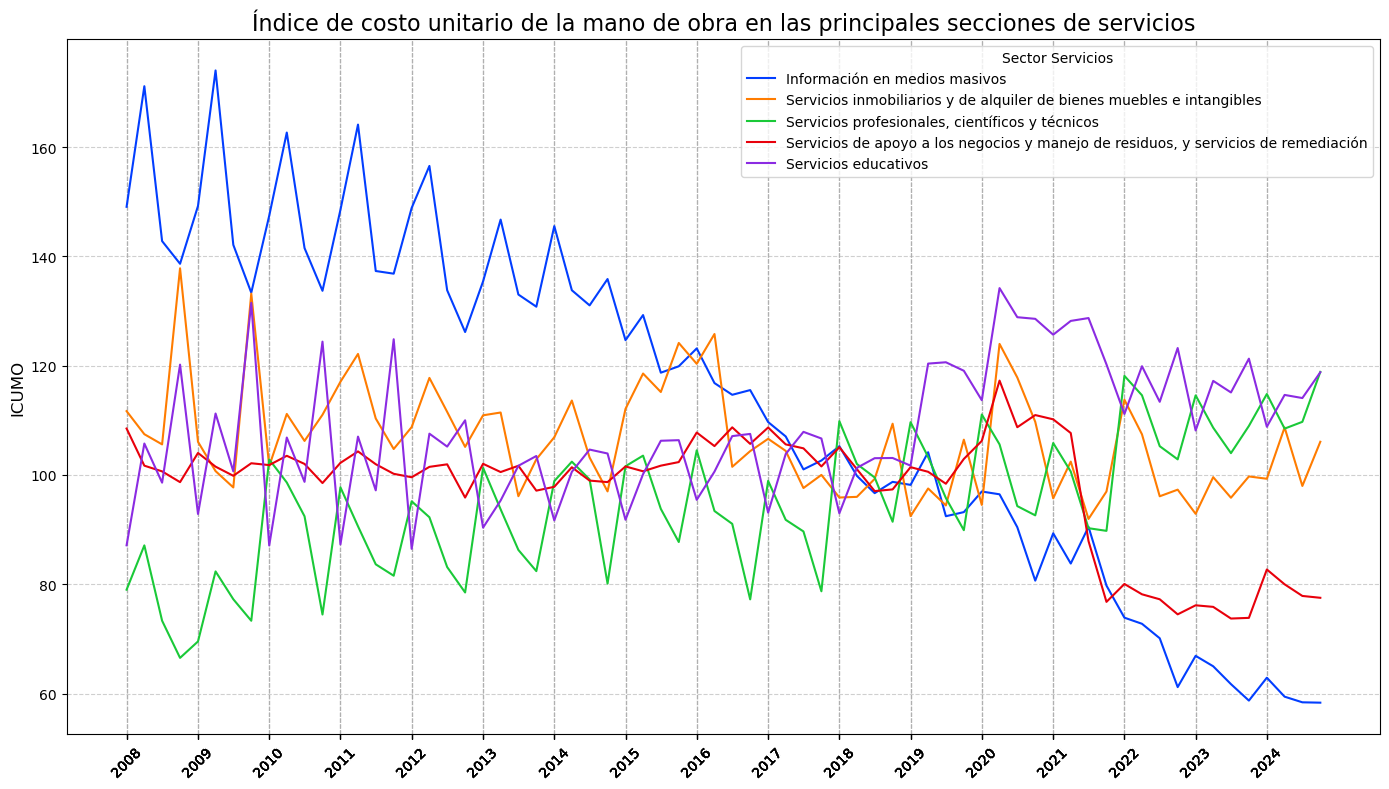

In [32]:
# Paso 7.5
df_servicios_mo = df_melted[(df_melted['Variable'] == 'Índice del costo unitario de la mano de obra con base en el personal ocupado total' ) & 
                                   (df_melted['Sector SCIAN'].isin(desempeno_servicios.head(5)['Sector SCIAN'].values))]

# Aplicar la función para quitar los dígitos al principio de las etiquetas
df_servicios_mo.loc[:, 'Sector SCIAN'] = df_servicios_mo['Sector SCIAN'].apply(quitar_digitos)
df_servicios_mo = df_servicios_mo[df_servicios_mo['FECHA'].dt.year >= 2008]

plt.figure(figsize=(14, 8))
sns.lineplot(
    data=df_servicios_mo,
    x='FECHA',
    y='VALOR',
    hue='Sector SCIAN',
    palette='bright',
)

plt.title('Índice de costo unitario de la mano de obra en las principales secciones de servicios', fontsize=16)
plt.ylabel('ICUMO', fontsize=12)
plt.xlabel('')

plt.xticks(
    ticks=df_servicios_mo['FECHA'][::4],
    labels=df_servicios_mo['FECHA'].dt.year[::4],
    rotation=45
)

plt.legend(title='Sector Servicios', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()